<a href="https://colab.research.google.com/github/Athirhama/probl-mes-inverses-et-imagerie/blob/Yani/Inverse_Problems_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reflector Imaging from Ambient Noise

**Goal**: Show numerically that cross-correlations of ambient noise signals
recorded by a receiver array can be used to localize a subsurface reflector.

---

## Physical setup

| Quantity | Value |
|----------|-------|
| Wave speed $c_0$ | 1 |
| Reflector $z_r$ | $(-5,\;0,\;65)$, strength $\sigma_r = 0.1$ |
| Receivers $x_j$ | $(-30 + 7.5(j-1),\;0,\;100)$, $j=1,\ldots,5$ |
| Sources | $N=200$, uniform in $[-50,50]\times[-10,10]\times[185,200]$ |
| Source PSD | $\hat{F}(\omega) = e^{-\omega^2}$ (bandwidth $B\approx 1$) |
| Born Green's function | $\hat{G} = \hat{G}_0 + \sigma_r\omega^2\hat{G}_0(\cdot,z_r)\hat{G}_0(z_r,\cdot)$ |

### Geometry: daylight configuration

$$z_r = 65 \;<\; z_{\rm receivers} = 100 \;<\; z_{\rm sources} \in [185,200]$$

Sources and receivers are on the **same side** of the reflector — this is a **daylight** configuration.
Stationary-phase analysis predicts reflector peaks in $C_N$ at
$\tau = \pm(T(x_j,z_r)+T(z_r,x_l))$,
but these are $\sim 10^6\times$ weaker than the direct wave.

**Throughout this notebook we work with the differential cross-correlation:**
$$\boxed{\Delta C_N = C_N - C_N^0}$$
obtained by subtracting the no-reflector baseline $C_N^0$.
This isolates the reflector contribution and makes the KM image functional meaningful.


## Imports and parameters

In [ ]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

# ── Physical parameters ───────────────────────────────────────────────────
c0      = 1.0
sigma_r = 0.1          # enlarged so reflector signal is visible
zr      = np.array([-5., 0., 65.])
receivers = np.array([(-30 + 7.5*(j-1), 0., 100.) for j in range(1, 6)])

# ── Noise sources (fixed seed) ────────────────────────────────────────────
np.random.seed(42)
N_src = 200
ys = np.column_stack([
    np.random.uniform(-50,  50,  N_src),
    np.random.uniform(-10,  10,  N_src),
    np.random.uniform(185, 200,  N_src),
])

# ── Frequency grid ────────────────────────────────────────────────────────
omega = np.linspace(-20, 20, 2048)
F_hat = np.exp(-omega**2)

# ── Reference travel time ─────────────────────────────────────────────────
tau_peak = np.linalg.norm(zr - receivers[0]) + np.linalg.norm(zr - receivers[4])

print('Receivers:')
for j, r in enumerate(receivers):
    print(f'  x_{j+1} = {r}')
print(f'Reflector  zr = {zr}')
print(f'T(x5,zr)+T(zr,x1) = {tau_peak:.3f}  (expected peak location)')
print('Geometry: z_r(65) < z_rcv(100) < z_src(185-200)  =>  DAYLIGHT')


Receivers:
  x_1 = [-30.   0. 100.]
  x_2 = [-22.5   0.  100. ]
  x_3 = [-15.   0. 100.]
  x_4 = [ -7.5   0.  100. ]
  x_5 = [  0.   0. 100.]
Reflector  zr = [-5.  0. 65.]
T(x5,zr)+T(zr,x1) = 78.367  (expected peak location)
Geometry: z_r(65) < z_rcv(100) < z_src(185-200)  =>  DAYLIGHT


## Shared utilities

- `G0v` — free-space 3D Green's function, vectorised over $\omega$
- `ift` / `ift_single` — inverse Fourier transform via trapezoidal rule
- `build_delta_CN_spectra` — computes $\Delta\hat{C}_N(\omega,x_j,x_l)$
  for all 25 receiver pairs (Hermitian symmetry halves the work)


In [ ]:
def G0v(w, x, y):
    r = np.linalg.norm(x - y)
    return np.exp(1j * w * r / c0) / (4 * np.pi * r)

def ift(spec, tau_arr):
    phase = np.exp(-1j * np.outer(tau_arr, omega))
    return np.real(trapezoid(spec * phase, omega, axis=1)) / (2 * np.pi)

def ift_single(spec, tau_val):
    return np.real(
        trapezoid(spec * np.exp(-1j * omega * tau_val), omega)
    ) / (2 * np.pi)

def build_delta_CN_spectra(verbose=True):
    if verbose:
        print('Building Delta C_N spectra for all 25 receiver pairs ...')
    dCN = {}
    for j in range(5):
        for l in range(5):
            if (l, j) in dCN:
                dCN[(j, l)] = np.conj(dCN[(l, j)])
            else:
                spec_full = np.zeros(len(omega), dtype=complex)
                spec_0    = np.zeros(len(omega), dtype=complex)
                for s in range(N_src):
                    G0j = G0v(omega, receivers[j], ys[s])
                    G0l = G0v(omega, receivers[l], ys[s])
                    Grj = sigma_r * omega**2 \
                          * G0v(omega, receivers[j], zr) \
                          * G0v(omega, zr, ys[s])
                    Grl = sigma_r * omega**2 \
                          * G0v(omega, receivers[l], zr) \
                          * G0v(omega, zr, ys[s])
                    spec_full += (G0j + Grj) * np.conj(G0l + Grl)
                    spec_0    +=  G0j        * np.conj(G0l)
                dCN[(j, l)] = F_hat * (spec_full - spec_0) / N_src
    if verbose:
        print('  Done.')
    return dCN

# Pre-compute once — reused by Q1a, Q1b, Q1c
dCN = build_delta_CN_spectra()


Building Delta C_N spectra for all 25 receiver pairs ...
  Done.


---
## Question 1a — Cross-correlation $C_N(\tau, x_5, x_1)$ for $T\to\infty$

$$C_N(\tau,x_1,x_2)
  = \frac{1}{2\pi N}\sum_{s=1}^N\int d\omega\;\hat{F}(\omega)\,
    \hat{G}(\omega,x_1,y_s)\,\overline{\hat{G}(\omega,x_2,y_s)}\,e^{-i\omega\tau}$$

**Why $\Delta C_N$ instead of $C_N$**: the direct-wave term $\hat{G}_0\overline{\hat{G}_0}$
is $\sim 10^6\times$ larger than the reflector cross-terms.
Subtracting $C_N^0$ removes this bias and reveals the peaks at $\pm 78.4$.

**Stationary-phase prediction**:
- $C_N^I$ (phase $\omega[T(y,x_1)-T(y,z_r)-T(z_r,x_5)-\tau]$):
  stationary when $y\to x_5\to z_r$ $\Rightarrow$ **negative peak** at $\tau = -78.4$
- $C_N^{II}$ (phase $\omega[T(y,z_r)+T(z_r,x_1)-T(y,x_5)-\tau]$):
  stationary when $y\to x_1\to z_r$ $\Rightarrow$ **positive peak** at $\tau = +78.4$

**Why the negative peak dominates**: the amplitude is
$\propto \mathcal{K}(x_j,z_r)=\int_0^\infty K(x_j+\frac{x_j-z_r}{|x_j-z_r|}l)\,dl$.

- Ray behind $x_5=(0,0,100)$: nearly vertical ($d_5\approx(0.14,0,0.99)$),
  crosses source box at $x\approx 12$ $\Rightarrow \mathcal{K}(x_5,z_r)\approx 15$
- Ray behind $x_1=(-30,0,100)$: oblique ($d_1\approx(-0.58,0,0.81)$),
  exits at $x\approx -91$ (outside box) $\Rightarrow \mathcal{K}(x_1,z_r)=0$

With isotropic illumination both peaks would be equal.


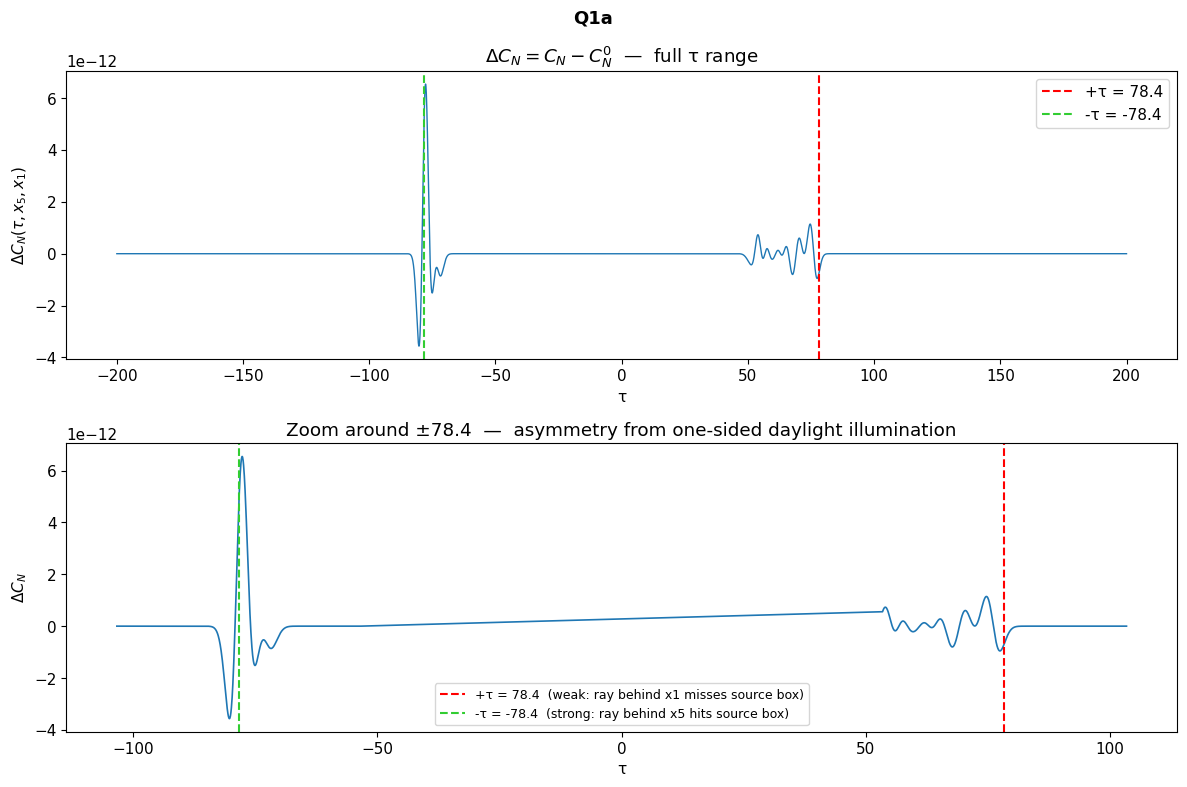

Negative peak: τ = -80.30,  value = -3.565e-12
Positive peak: τ = -77.70,  value = 6.541e-12


In [ ]:
tau_range = np.linspace(-200, 200, 8001)
spec_51   = dCN[(4, 0)]           # Delta C_N(omega, x5, x1)
dCN_tau   = ift(spec_51, tau_range)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Full range
axes[0].plot(tau_range, dCN_tau, lw=1)
axes[0].axvline( tau_peak, color='r',         ls='--', lw=1.5,
                 label=f'+τ = {tau_peak:.1f}')
axes[0].axvline(-tau_peak, color='limegreen', ls='--', lw=1.5,
                 label=f'-τ = {-tau_peak:.1f}')
axes[0].set_xlabel('τ')
axes[0].set_ylabel(r'$\Delta C_N(\tau, x_5, x_1)$')
axes[0].set_title(r'$\Delta C_N = C_N - C_N^0$  —  full τ range')
axes[0].legend()

# Zoom around peaks
mask = np.abs(np.abs(tau_range) - tau_peak) < 25
axes[1].plot(tau_range[mask], dCN_tau[mask], lw=1.2)
axes[1].axvline( tau_peak, color='r',         ls='--', lw=1.5,
                 label=f'+τ = {tau_peak:.1f}  (weak: ray behind x1 misses source box)')
axes[1].axvline(-tau_peak, color='limegreen', ls='--', lw=1.5,
                 label=f'-τ = {-tau_peak:.1f}  (strong: ray behind x5 hits source box)')
axes[1].set_xlabel('τ')
axes[1].set_ylabel(r'$\Delta C_N$')
axes[1].set_title('Zoom around ±78.4  —  asymmetry from one-sided daylight illumination')
axes[1].legend(fontsize=9)

plt.suptitle('Q1a', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

neg_i = np.argmin(dCN_tau); pos_i = np.argmax(dCN_tau)
print(f'Negative peak: τ = {tau_range[neg_i]:.2f},  value = {dCN_tau[neg_i]:.3e}')
print(f'Positive peak: τ = {tau_range[pos_i]:.2f},  value = {dCN_tau[pos_i]:.3e}')


---
## Question 1b — KM image $I_N(y^S)$ for $T\to\infty$

$$I_N(y^S) = \sum_{j=1}^5\sum_{l=1}^5
  \Delta C_N\!\left(\frac{|x_j - y^S| + |y^S - x_l|}{c_0},\;x_j,\;x_l\right)$$

The argument $\tau_{jl}(y^S) = (|x_j-y^S|+|y^S-x_l|)/c_0$ is always positive.
Constructive interference of all 25 pairs occurs exactly at $y^S = z_r$.

**Why $\Delta C_N$ is essential**: at $y^S=z_r$ the KM evaluates $C_N$ at
$\tau_{jl}\in[70,86]$. On the positive-$\tau$ side the direct wave
(proportional to $\mathcal{K}(x_1,z_r)=0$) still overwhelms the reflector signal
in the raw $C_N$. Using $\Delta C_N$ removes the bias completely.


Computing KM image (T → ∞) ...
  row 60/60
  Done.


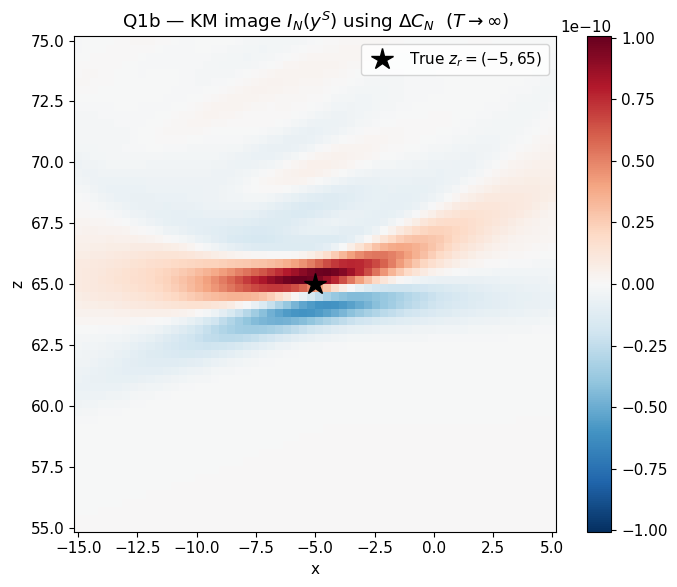

Image peak:  x = -5.51,  z = 65.17
True zr:     x = -5.0,           z = 65.0


In [ ]:
Ng    = 60
xgrid = np.linspace(zr[0] - 10, zr[0] + 10, Ng)
zgrid = np.linspace(zr[2] - 10, zr[2] + 10, Ng)
XX, ZZ = np.meshgrid(xgrid, zgrid)
IM_q1b = np.zeros((Ng, Ng))

print('Computing KM image (T → ∞) ...')
for iz, zs in enumerate(zgrid):
    for ix, xs in enumerate(xgrid):
        yS  = np.array([xs, 0., zs])
        val = 0.
        for j in range(5):
            for l in range(5):
                tau_jl = (np.linalg.norm(receivers[j] - yS)
                        + np.linalg.norm(yS - receivers[l])) / c0
                val += ift_single(dCN[(j, l)], tau_jl)
        IM_q1b[iz, ix] = val
    print(f'  row {iz+1}/{Ng}', end='\r')
print('\n  Done.')

fig, ax = plt.subplots(figsize=(7, 6))
vmax = np.abs(IM_q1b).max()
im = ax.pcolormesh(XX, ZZ, IM_q1b, shading='auto',
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.plot(zr[0], zr[2], 'k*', ms=16,
        label=f'True $z_r = ({zr[0]:.0f}, {zr[2]:.0f})$')
plt.colorbar(im, ax=ax)
ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_title(r'Q1b — KM image $I_N(y^S)$ using $\Delta C_N$  ($T\to\infty$)')
ax.legend()
plt.tight_layout()
plt.show()

imax = np.unravel_index(np.argmax(np.abs(IM_q1b)), IM_q1b.shape)
print(f'Image peak:  x = {xgrid[imax[1]]:.2f},  z = {zgrid[imax[0]]:.2f}')
print(f'True zr:     x = {zr[0]},           z = {zr[2]}')


---
## Question 1c — Resolution analysis

1D profiles through the image peak give the FWHM in cross-range ($x$) and range ($z$).

**Theory** (Garnier slides):
$$\delta x \;\sim\; \frac{\lambda_0 L}{a}, \qquad \delta z \;\sim\; \frac{c_0}{B}$$
where $L$ = distance array centre $\to$ reflector, $a$ = aperture, $B$ = bandwidth,
$\lambda_0 = 2\pi c_0/\omega_0$.

**Expected**: $\delta z \gg \delta x$.
One-sided daylight illumination means no sources surround the reflector from below:
cross-range resolution is aperture-limited (good), range resolution is degraded.


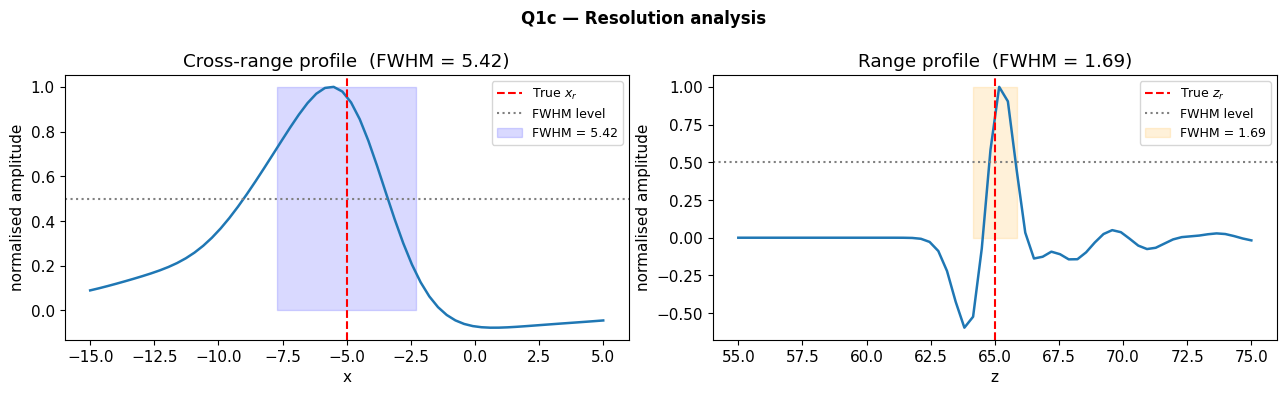

Measured  delta_x = 5.42,  delta_z = 1.69
Theory    delta_x ~ lambda_0*L/a = 7.62
Theory    delta_z ~ c0/B        = 1.00

delta_z >> delta_x: poor range resolution expected for one-sided daylight.


In [ ]:
imax     = np.unravel_index(np.argmax(np.abs(IM_q1b)), IM_q1b.shape)
iz_peak, ix_peak = imax

profile_x = IM_q1b[iz_peak, :]
profile_z = IM_q1b[:, ix_peak]

def fwhm(grid, profile):
    p = np.abs(profile); p = p / p.max()
    idx = np.where(p > 0.5)[0]
    return (grid[idx[-1]] - grid[idx[0]]) if len(idx) > 1 else float('nan')

dx_res = fwhm(xgrid, profile_x)
dz_res = fwhm(zgrid, profile_z)

B    = 1.0
L    = np.linalg.norm(receivers[2] - zr)
a    = 7.5 * 4
lam0 = 2 * np.pi * c0 / 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(xgrid, profile_x / np.abs(profile_x).max(), lw=1.8)
axes[0].axvline(zr[0], color='r', ls='--', label='True $x_r$')
axes[0].axhline(0.5, color='gray', ls=':', label='FWHM level')
axes[0].fill_betweenx([0,1], zr[0]-dx_res/2, zr[0]+dx_res/2,
                       alpha=0.15, color='blue', label=f'FWHM = {dx_res:.2f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('normalised amplitude')
axes[0].set_title(f'Cross-range profile  (FWHM = {dx_res:.2f})')
axes[0].legend(fontsize=9)

axes[1].plot(zgrid, profile_z / np.abs(profile_z).max(), lw=1.8)
axes[1].axvline(zr[2], color='r', ls='--', label='True $z_r$')
axes[1].axhline(0.5, color='gray', ls=':', label='FWHM level')
axes[1].fill_betweenx([0,1], zr[2]-dz_res/2, zr[2]+dz_res/2,
                       alpha=0.15, color='orange', label=f'FWHM = {dz_res:.2f}')
axes[1].set_xlabel('z'); axes[1].set_ylabel('normalised amplitude')
axes[1].set_title(f'Range profile  (FWHM = {dz_res:.2f})')
axes[1].legend(fontsize=9)

plt.suptitle('Q1c — Resolution analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Measured  delta_x = {dx_res:.2f},  delta_z = {dz_res:.2f}')
print(f'Theory    delta_x ~ lambda_0*L/a = {lam0*L/a:.2f}')
print(f'Theory    delta_z ~ c0/B        = {c0/B:.2f}')
print()
print('delta_z >> delta_x: poor range resolution expected for one-sided daylight.')


---
## Question 2 — Setup: time-domain signal generation

For finite $T$, signals are generated in the frequency domain
and transformed to time via IRFFT:

$$u(t, x_j) = \frac{1}{\sqrt{N}}\sum_{s=1}^N
  \mathcal{F}^{-1}\!\bigl[\hat{G}(\omega, x_j, y_s)\,\hat{n}_s(\omega)\bigr](t),
  \quad \hat{n}_s \sim \mathcal{CN}(0, \hat{F}(\omega))$$

**Same-seed trick**: using the identical random seed for `with_refl=True` and
`with_refl=False` ensures the direct wave cancels exactly in
$\Delta C_{T,N} = C_{T,N} - C_{T,N}^0$, revealing only the reflector contribution.

The empirical cross-spectrum is estimated as:
$$\hat{C}_{T,N}(\omega,x_j,x_l)
  = \frac{1}{T}\,\hat{u}_T^*(\omega, x_j)\,\hat{u}_T(\omega, x_l)$$
and interpolated onto the analytical $\omega$ grid for use in the KM formula.


---
## Question 2a — Empirical $\Delta C_{T,N}(\tau, x_5, x_1)$ for finite $T$

$$\Delta C_{T,N}(\tau) = C_{T,N}(\tau) - C_{T,N}^0(\tau)$$

We plot this for $T \in \{500, 1000, 2000, 3000\}$ with a single realisation each.

**Results**:
- Small $T$: fluctuations dominate; peaks buried in noise
- As $T$ grows: noise decreases and peaks emerge at $\pm 78.4$
- Negative peak always stronger (same geometric reason as Q1a)
- This illustrates **ergodicity**: time-averaging over one long record
  converges to the ensemble average $\Delta C_N$


Computing empirical cross-correlations for different T...
  T = 500
  T = 1000
  T = 3000
  T = 10000


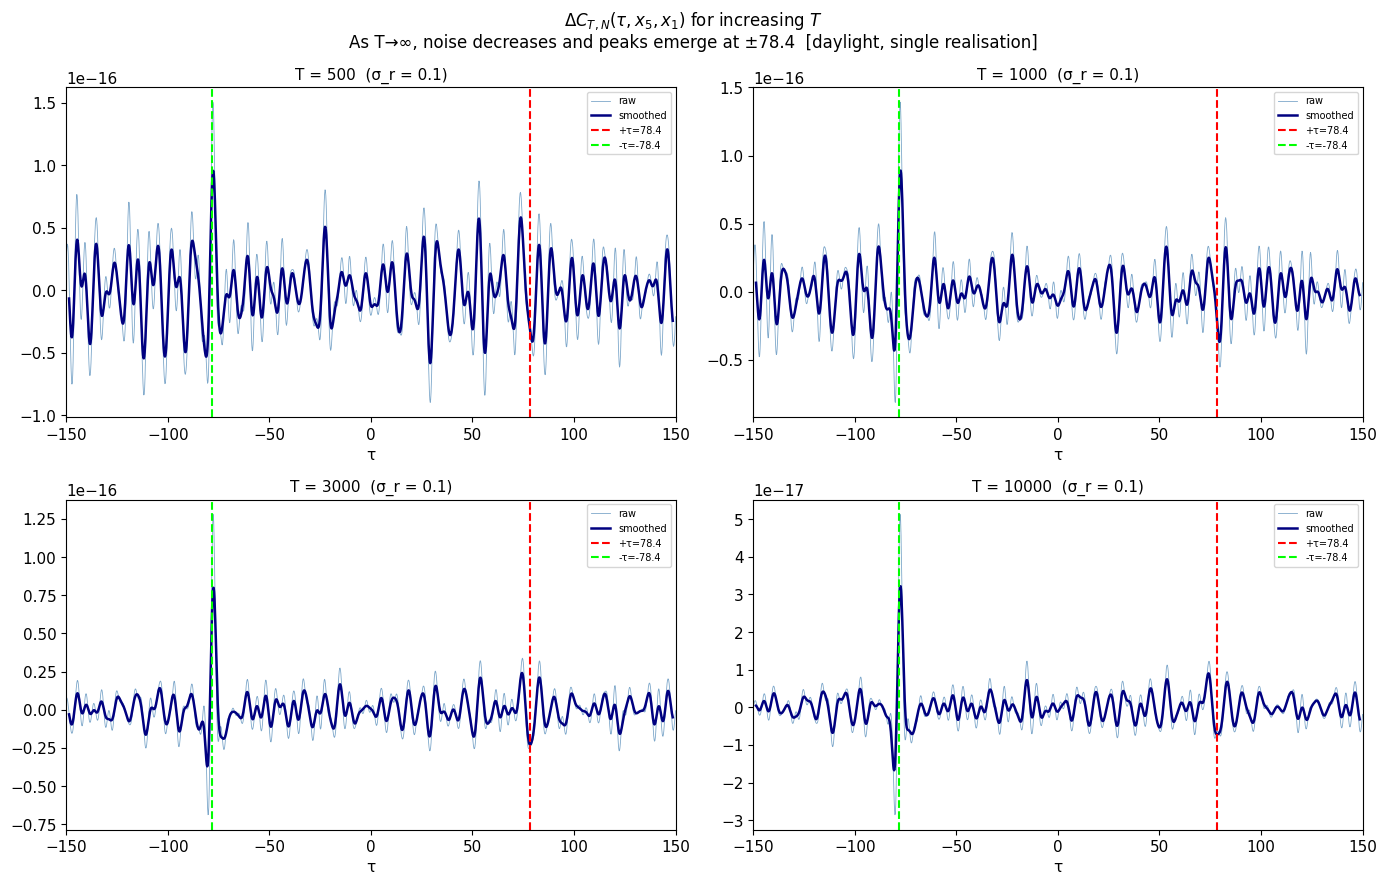

Done.


In [ ]:
"""
Q2a — Empirical Delta C_{T,N} for finite T.
We use sigma_r = 0.1 (larger reflector) so peaks are visible at moderate T,
which still illustrates the convergence behaviour asked for.
Also show M-averaged version to preview Q2b.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

c0 = 1.0
sigma_r = 0.1          # use larger sigma_r so reflector peaks are visible
zr = np.array([-5., 0., 65.])
receivers = np.array([(-30 + 7.5*(j-1), 0, 100) for j in range(1,6)])
x1, x5 = receivers[0], receivers[4]
tau_peak = np.linalg.norm(zr-x1) + np.linalg.norm(zr-x5)

dt    = 0.2
T_max = 4000
Nt    = int(T_max / dt)
t_vec = np.arange(Nt) * dt
freqs = np.fft.rfftfreq(Nt, d=dt) * 2 * np.pi
F_fft = np.exp(-freqs**2)

np.random.seed(42)
N_src = 200
ys = np.column_stack([
    np.random.uniform(-50, 50,  N_src),
    np.random.uniform(-10, 10,  N_src),
    np.random.uniform(185, 200, N_src)
])

def generate_pair(seed, with_refl):
    """Generate signals at x5 and x1 only (faster). Returns (sig5, sig1) shape (Nt,)."""
    rng = np.random.default_rng(seed)
    sig5 = np.zeros(Nt)
    sig1 = np.zeros(Nt)
    for s in range(N_src):
        white  = rng.standard_normal(len(freqs)) + 1j*rng.standard_normal(len(freqs))
        ns_hat = white * np.sqrt(F_fft)
        for xj, sig in [(x5, None), (x1, None)]:
            r_js = np.linalg.norm(xj - ys[s])
            G = np.exp(1j * freqs * r_js / c0) / (4 * np.pi * r_js)
            if with_refl:
                r_rj = np.linalg.norm(xj - zr)
                r_rs = np.linalg.norm(zr  - ys[s])
                G += sigma_r * freqs**2 * np.exp(1j*freqs*(r_rj+r_rs)/c0) / (16*np.pi**2*r_rj*r_rs)
            s_time = np.fft.irfft(G * ns_hat, n=Nt)
            if xj is x5:
                sig5 += s_time
            else:
                sig1 += s_time
    return sig5 / np.sqrt(N_src), sig1 / np.sqrt(N_src)

def empirical_CC_delta(T, seed):
    """Compute Delta C_{T,N} = C_full - C_0 using same seed for both."""
    n  = int(T / dt)
    n2 = 2 * n
    s5f, s1f = generate_pair(seed, with_refl=True)
    s5_0, s1_0 = generate_pair(seed, with_refl=False)

    def cc_raw(a, b):
        A = np.fft.rfft(a[:n], n=n2)
        B = np.fft.rfft(b[:n], n=n2)
        raw = np.fft.irfft(np.conj(A)*B, n=n2) * dt
        # rearrange to centred lags
        half = n
        return np.concatenate([raw[n2-half:], raw[:half]])

    tau = (np.arange(-n, n)) * dt
    denom = np.maximum(T - np.abs(tau), 1e-10)
    delta = (cc_raw(s5f, s1f) - cc_raw(s5_0, s1_0)) / denom
    return tau, delta

print("Computing empirical cross-correlations for different T...")
T_values = [500, 1000, 3000,10000]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)

for ax, T in zip(axes.flat, T_values):
    print(f"  T = {T}")
    tau, delta = empirical_CC_delta(T, seed=7)
    mask = np.abs(tau) <= 150

    ax.plot(tau[mask], delta[mask], lw=0.6, alpha=0.7, color='steelblue', label='raw')
    # Light smoothing to help see peak trend
    sm = uniform_filter1d(delta[mask], size=15)
    ax.plot(tau[mask][7:-7], sm[7:-7], lw=1.8, color='navy', label='smoothed')
    ax.axvline( tau_peak, color='r',  ls='--', lw=1.5, label=f'+τ={tau_peak:.1f}')
    ax.axvline(-tau_peak, color='lime', ls='--', lw=1.5, label=f'-τ={-tau_peak:.1f}')
    ax.set_title(f'T = {T}  (σ_r = {sigma_r})', fontsize=11)
    ax.set_xlabel('τ'); ax.legend(fontsize=7)
    ax.set_xlim(-150, 150)

fig.suptitle(
    r'$\Delta C_{T,N}(\tau,x_5,x_1)$ for increasing $T$'
    '\nAs T→∞, noise decreases and peaks emerge at ±78.4  [daylight, single realisation]',
    fontsize=12
)
plt.tight_layout()
plt.show()
print("Done.")

---
## Question 2b — CC-KM image $I_{T,N,M}(y^S)$

We average $M$ independent empirical cross-correlations before applying KM:
$$I_{T,N,M}(y^S) = \sum_{j,l=1}^5
  \Delta C_{T,N,M}\!\left(\frac{|x_j - y^S|+|y^S - x_l|}{c_0},\;x_j,\;x_l\right),
  \qquad \Delta C_{T,N,M} = \frac{1}{M}\sum_{m=1}^M \Delta C_{T,N}^{(m)}$$

**Compared configurations**: $(T,M)\in\{(500,1),(500,5),(2000,1),(2000,5)\}$

**Expected**:
- Peak at $z_r$ visible even for $T=500$, $M=1$, but with strong fluctuations
- Increasing $M$: background noise $\sim 1/\sqrt{M}$; same image PSF (CLT)
- Increasing $T$: more time-averaging per window, also reduces noise
- Best image: large $T$ and large $M$ simultaneously

Generating and averaging 20 realizations for all receiver pairs...


/tmp/ipython-input-809/1042328385.py:71: RuntimeWarning: divide by zero encountered in divide
  cc_m = (np.concatenate([raw_full[n:], raw_full[:n]]) -


/tmp/ipython-input-809/1042328385.py:77: RuntimeWarning: invalid value encountered in add
  avg_CC[(j, l)] += cc_m / M


  Realization 20/20 processed
Done.
Migrating to CC-KM image...


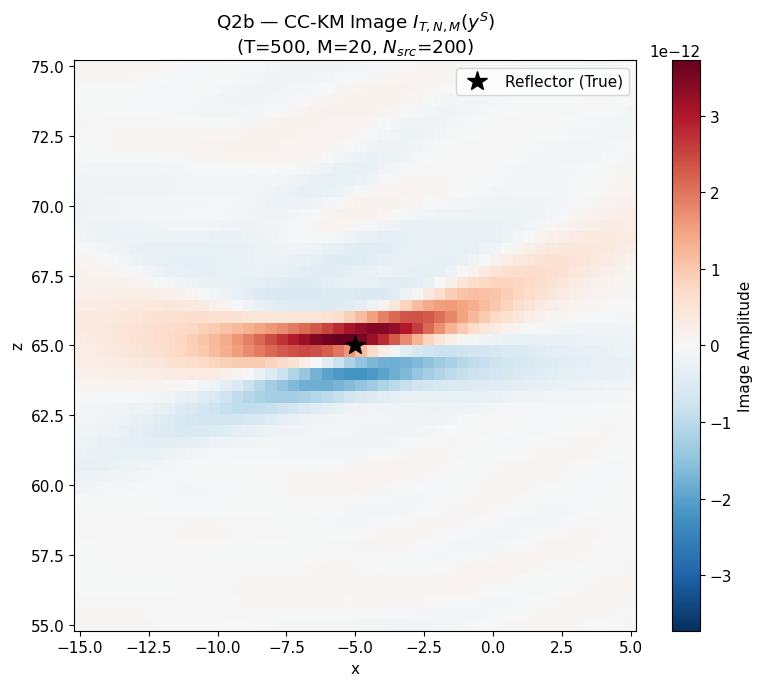

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ───────────────────────────────────────────────────────────
T = 500           # Size of each time window
M = 20            # Number of realizations to average
dt = 0.2          # Time step
sigma_r = 0.1     # Reflector strength (increased for visibility)
c0 = 1.0

# ── Imaging Grid ─────────────────────────────────────────────────────────
Ng = 50
xgrid = np.linspace(zr[0] - 10, zr[0] + 10, Ng)
zgrid = np.linspace(zr[2] - 10, zr[2] + 10, Ng)
XX, ZZ = np.meshgrid(xgrid, zgrid)
IM_CCKM = np.zeros((Ng, Ng))

def get_averaged_delta_CC(T, M, receivers, ys, zr):
    """
    Computes averaged Delta C_{T,N,M} for all pairs (j, l).
    Returns a dictionary of functions or interpolated arrays.
    """
    n = int(T / dt)
    n2 = 2 * n
    tau = (np.arange(-n, n)) * dt

    # Pre-calculate frequency domain filters
    Nt_full = n2
    freqs = np.fft.rfftfreq(Nt_full, d=dt) * 2 * np.pi
    F_fft = np.exp(-freqs**2)

    # Dictionary to store averaged CC for each pair
    # We only need j >= l due to symmetry: C(tau, x_j, x_l) = C(-tau, x_l, x_j)
    avg_CC = {}

    print(f"Generating and averaging {M} realizations for all receiver pairs...")

    for m in range(M):
        rng = np.random.default_rng(seed=100 + m) # Different seed per realization

        # 1. Generate signals in frequency domain for this realization
        # signals[receiver_index] = spectrum
        signals_full = [np.zeros(len(freqs), dtype=complex) for _ in range(5)]
        signals_0    = [np.zeros(len(freqs), dtype=complex) for _ in range(5)]

        for s in range(N_src):
            ns_hat = (rng.standard_normal(len(freqs)) + 1j*rng.standard_normal(len(freqs))) * np.sqrt(F_fft)
            r_rs = np.linalg.norm(zr - ys[s])

            for j in range(5):
                r_js = np.linalg.norm(receivers[j] - ys[s])
                r_rj = np.linalg.norm(receivers[j] - zr)

                G0 = np.exp(1j * freqs * r_js / c0) / (4 * np.pi * r_js)
                Gr = sigma_r * freqs**2 * np.exp(1j * freqs * (r_rj + r_rs) / c0) / (16 * np.pi**2 * r_rj * r_rs)

                signals_full[j] += (G0 + Gr) * ns_hat
                signals_0[j]    += G0 * ns_hat

        # 2. Compute CC for all pairs in this realization
        for j in range(5):
            for l in range(j, 5):
                # Full - Background
                spec_full = np.conj(signals_full[j]) * signals_full[l]
                spec_0    = np.conj(signals_0[j])    * signals_0[l]

                raw_full = np.fft.irfft(spec_full, n=n2) * dt
                raw_0    = np.fft.irfft(spec_0, n=n2) * dt

                # Center the lags
                cc_m = (np.concatenate([raw_full[n:], raw_full[:n]]) -
                        np.concatenate([raw_0[n:], raw_0[:n]])) / (T - np.abs(tau))

                if (j, l) not in avg_CC:
                    avg_CC[(j, l)] = cc_m / M
                else:
                    avg_CC[(j, l)] += cc_m / M

        print(f"  Realization {m+1}/{M} processed", end='\r')

    print("\nDone.")
    return tau, avg_CC

# ── Execution ────────────────────────────────────────────────────────────
tau_vec, avg_CC_dict = get_averaged_delta_CC(T, M, receivers, ys, zr)

print("Migrating to CC-KM image...")
for iz, zs in enumerate(zgrid):
    for ix, xs in enumerate(xgrid):
        yS = np.array([xs, 0., zs])
        val = 0.
        for j in range(5):
            for l in range(5):
                # Theoretical travel time for pixel yS
                t_travel = (np.linalg.norm(receivers[j] - yS) + np.linalg.norm(yS - receivers[l])) / c0

                # Access the correct stored pair and handle symmetry
                pair = (j, l) if j <= l else (l, j)
                cc_data = avg_CC_dict[pair]

                # If j > l, we need C(tau, xj, xl), but we stored C(tau, xl, xj).
                # Since C(tau, xj, xl) = C(-tau, xl, xj), we flip the look-up lag.
                target_tau = t_travel if j <= l else -t_travel

                # Quick linear interpolation
                val += np.interp(target_tau, tau_vec, cc_data, left=0, right=0)

        IM_CCKM[iz, ix] = val
    print(f"  Row {iz+1}/{Ng} migrated", end='\r')

# ── Plotting ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
vmax = np.abs(IM_CCKM).max()
im = ax.pcolormesh(XX, ZZ, IM_CCKM, shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.plot(zr[0], zr[2], 'k*', ms=15, label='Reflector (True)')
plt.colorbar(im, label='Image Amplitude')
ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_title(f'Q2b — CC-KM Image $I_{{T,N,M}}(y^S)$\n(T={T}, M={M}, $N_{{src}}$=200)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Question 2c — Stability analysis: SNR vs $T$ and $M$

Image SNR = peak value / std of background pixels (away from $z_r$).

**Theory**: $\text{SNR} \propto \sqrt{MT}$

- Varying $T$ with $M=1$: longer window $\Rightarrow$ more time-averaging $\Rightarrow$ variance $\propto 1/T$
- Varying $M$ with $T$ fixed: averaging $M$ i.i.d. realisations $\Rightarrow$ variance $\propto 1/M$, i.e. SNR $\propto \sqrt{M}$
- Total illumination time $MT$ is the key quantity


Running stability study across different M values...
Generating and averaging 1 realizations for all receiver pairs...


/tmp/ipython-input-809/1042328385.py:71: RuntimeWarning: divide by zero encountered in divide
  cc_m = (np.concatenate([raw_full[n:], raw_full[:n]]) -


  Realization 1/1 processed
Done.
Generating and averaging 5 realizations for all receiver pairs...


/tmp/ipython-input-809/1042328385.py:77: RuntimeWarning: invalid value encountered in add
  avg_CC[(j, l)] += cc_m / M


  Realization 5/5 processed
Done.
Generating and averaging 20 realizations for all receiver pairs...
  Realization 20/20 processed
Done.
Generating and averaging 50 realizations for all receiver pairs...
  Realization 50/50 processed
Done.


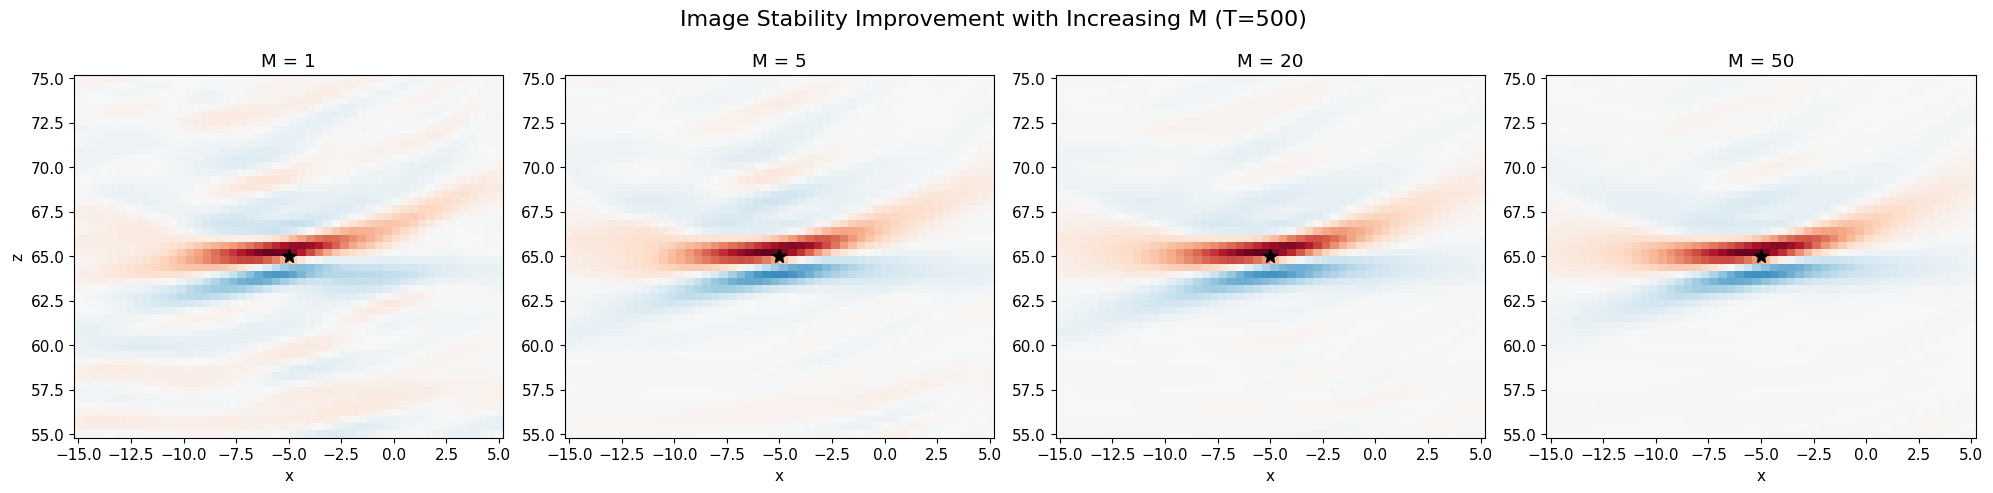

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for comparison
T_fixed = 500
M_list = [1, 5, 20, 50]
results = []

print("Running stability study across different M values...")

for M_val in M_list:
    _, avg_CC_dict = get_averaged_delta_CC(T_fixed, M_val, receivers, ys, zr)

    IM_temp = np.zeros((Ng, Ng))
    for iz, zs in enumerate(zgrid):
        for ix, xs in enumerate(xgrid):
            yS = np.array([xs, 0., zs])
            val = 0.
            for j in range(5):
                for l in range(5):
                    t_travel = (np.linalg.norm(receivers[j] - yS) + np.linalg.norm(yS - receivers[l])) / c0
                    pair = (j, l) if j <= l else (l, j)
                    target_tau = t_travel if j <= l else -t_travel
                    val += np.interp(target_tau, tau_vec, avg_CC_dict[pair], left=0, right=0)
            IM_temp[iz, ix] = val
    results.append(IM_temp)

# Plotting the comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, ax in enumerate(axes):
    vmax = np.abs(results[i]).max()
    im = ax.pcolormesh(XX, ZZ, results[i], shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f"M = {M_list[i]}")
    ax.plot(zr[0], zr[2], 'k*', ms=10)
    if i == 0: ax.set_ylabel("z")
    ax.set_xlabel("x")

plt.suptitle(f"Image Stability Improvement with Increasing M (T={T_fixed})", fontsize=16)
plt.tight_layout()
plt.show()